In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [2]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

C:\Users\victo\AppData\Local\Temp\ipykernel_30036\4168379563.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


In [3]:
data[data["gameid"] == "LOLTMNT03_237611"]

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
59256,LOLTMNT03_237611,complete,NaN,LJL,2025,NaN,0,2025-05-18 08:06:39,1,15.1,...,175.0,791.0,-1052.0,3.0,1.0,6.0,5.0,2.0,5.0,7.0
59257,LOLTMNT03_237611,complete,NaN,LJL,2025,NaN,0,2025-05-18 08:06:39,1,15.1,...,157.0,-1671.0,-2532.0,2.0,5.0,8.0,9.0,11.0,11.0,3.0
59258,LOLTMNT03_237611,complete,NaN,LJL,2025,NaN,0,2025-05-18 08:06:39,1,15.1,...,180.0,882.0,-1602.0,-11.0,5.0,7.0,7.0,7.0,11.0,2.0
59259,LOLTMNT03_237611,complete,NaN,LJL,2025,NaN,0,2025-05-18 08:06:39,1,15.1,...,195.0,-4347.0,-2133.0,-48.0,6.0,8.0,5.0,14.0,8.0,3.0
59260,LOLTMNT03_237611,complete,NaN,LJL,2025,NaN,0,2025-05-18 08:06:39,1,15.1,...,17.0,757.0,-932.0,8.0,2.0,12.0,9.0,0.0,17.0,4.0
59261,LOLTMNT03_237611,complete,NaN,LJL,2025,NaN,0,2025-05-18 08:06:39,1,15.1,...,178.0,-791.0,1052.0,-3.0,2.0,5.0,7.0,1.0,6.0,5.0
59262,LOLTMNT03_237611,complete,NaN,LJL,2025,NaN,0,2025-05-18 08:06:39,1,15.1,...,159.0,1671.0,2532.0,-2.0,11.0,11.0,3.0,5.0,8.0,9.0
59263,LOLTMNT03_237611,complete,NaN,LJL,2025,NaN,0,2025-05-18 08:06:39,1,15.1,...,169.0,-882.0,1602.0,11.0,7.0,11.0,2.0,5.0,7.0,7.0
59264,LOLTMNT03_237611,complete,NaN,LJL,2025,NaN,0,2025-05-18 08:06:39,1,15.1,...,147.0,4347.0,2133.0,48.0,14.0,8.0,3.0,6.0,8.0,5.0
59265,LOLTMNT03_237611,complete,NaN,LJL,2025,NaN,0,2025-05-18 08:06:39,1,15.1,...,25.0,-757.0,932.0,-8.0,0.0,17.0,4.0,2.0,12.0,9.0


In [4]:
data = data.drop(data[data["position"] == "team"].index) 

In [5]:
#dropping columns drops international event data as it has a lot of missing data, but we do not need that data for this, so do not drop data
"""
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)
"""
# but there are a few players with missing playerids, we still need to remove these players for our graph mining as we use the playerids to describe the players
missing_playerids = data[data["playerid"].isna()]
missing_players = missing_playerids["playername"].unique()
games_with_missing_playerids = data[data["gameid"].isin(missing_playerids["gameid"].unique())] 
print(f"there are {len(missing_playerids)} player performances without an associated playerid and {len(missing_players)} unique player names associated with those performances, we remove all of these")
data = data.drop(games_with_missing_playerids.index)


there are 1803 player performances without an associated playerid and 237 unique player names associated with those performances, we remove all of these


Make sure all games have exactly 10 player performances

In [6]:
np.all(data["gameid"].value_counts() == 10)

np.True_

In [7]:
uniq_player_ids = data["playerid"].unique()
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

In [8]:
len(uniq_player_ids)

2567

In [9]:
for i in tqdm(range(0, len(data), 10)):
    player_ids = []
    for j in range(10):
        player_ids.append(data.iloc[i + j]["playerid"])
    
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

  0%|          | 0/9691 [00:00<?, ?it/s]

In [10]:
for j in range(adj_matrix.shape[0]):
    adj_matrix[j,j] = 0

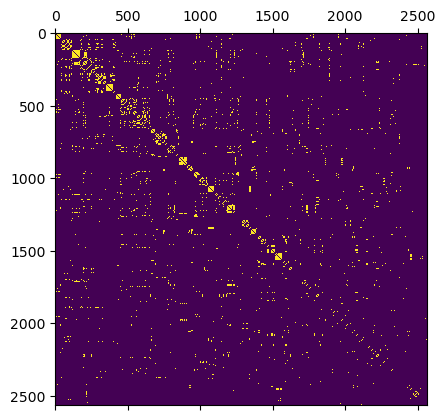

In [11]:
plt.matshow(adj_matrix)

In [12]:
z = sklearn.cluster.spectral_clustering(adj_matrix, n_clusters=5)

In [13]:
league_to_region_dict = {"LFL2":"EU", 
"LPL": "CN", 
"LCKC": "KR", 
"LVP SL": "EU", 
"LCK" : "KR", 
"NLC": "EU", 
"LCP": "APAC",
"LEC": "EU",
"HLL": "EU",
"PRM": "EU", 
"LFL": "EU",
"LIT": "EU",
"TCL": "EU",
"HW": "EU",
"LJL": "JP",
"LTA S": "LAT",
"LTA N": "NA",
"RL": "EU",
"NEXO": "EU", 
"CD": "LAT",
"EBL": "EU",
"PCS": "APAC", 
"ROL": "EU",
"LPLOL": "EU", 
"AL": "EU",
"LTA": "NA",
"VCS": "APAC",
"FST": "INT",
"EM": "EU",
"LRS": "LAT",
"LRN": "LAT",
"NACL": "NA", 
"LAS": "KR",
"HC": "EU", 
"PRMP": "EU",
"HM": "EU", 
"CT": "EU",
"Asia Master": "INT",
"MSI": "INT",
"EWC": "INT",
"WLDs": "INT",
"ASI": "INT",
"IC": "EU",
"KeSPA": "KR",
"DCup": "CN"
}

In [14]:
regions = dict.fromkeys(set(league_to_region_dict.values()), 0)
regions

{'NA': 0, 'APAC': 0, 'JP': 0, 'EU': 0, 'CN': 0, 'LAT': 0, 'KR': 0, 'INT': 0}

In [15]:
from utils import visualize

visualize.count_cluster_regions(z, uniq_player_ids, data)

0
{'NA': 3, 'APAC': 3, 'JP': 0, 'EU': 2008, 'CN': 0, 'LAT': 2, 'KR': 0, 'INT': 0}
__
1
{'NA': 0, 'APAC': 0, 'JP': 0, 'EU': 216, 'CN': 0, 'LAT': 0, 'KR': 0, 'INT': 0}
__
2
{'NA': 4, 'APAC': 0, 'JP': 0, 'EU': 0, 'CN': 0, 'LAT': 221, 'KR': 0, 'INT': 0}
__
3
{'NA': 124, 'APAC': 0, 'JP': 0, 'EU': 1, 'CN': 0, 'LAT': 103, 'KR': 0, 'INT': 0}
__
4
{'NA': 93, 'APAC': 244, 'JP': 70, 'EU': 56, 'CN': 175, 'LAT': 37, 'KR': 298, 'INT': 470}
__


In [16]:
colors = ["#f9c80e", "#f86624", "#ea3546", "#662e9b", "#43bccd"]

color_labels = [colors[x] for x in z]

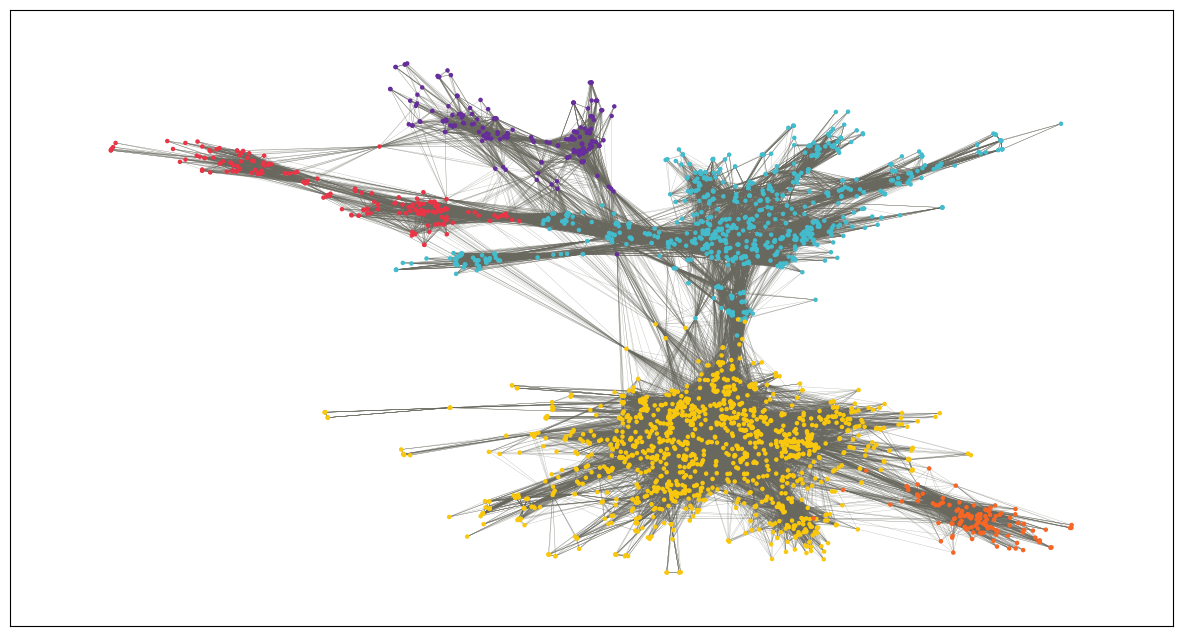

In [17]:
import networkx as nx
plt.figure(figsize=(15,8))
G = nx.from_numpy_array(adj_matrix)
layout = nx.spring_layout(G, seed=1)
nx.draw_networkx_nodes(G, layout, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

In [18]:
import sknetwork as skn
spectral = skn.embedding.Spectral(n_components=3)
embedding = spectral.fit_transform(adj_matrix)

In [19]:
adj_matrix.shape

(2567, 2567)

In [20]:
embedding.shape

(2567, 3)

In [21]:
np.unique(z)

array([0, 1, 2, 3, 4], dtype=int32)

In [22]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0, n_init='auto').fit(embedding)

In [23]:
visualize.count_cluster_regions(kmeans.labels_, uniq_player_ids, data)

0
{'NA': 145, 'APAC': 0, 'JP': 0, 'EU': 1, 'CN': 0, 'LAT': 348, 'KR': 0, 'INT': 0}
__
1
{'NA': 3, 'APAC': 1, 'JP': 0, 'EU': 1990, 'CN': 0, 'LAT': 2, 'KR': 0, 'INT': 0}
__
2
{'NA': 1, 'APAC': 246, 'JP': 70, 'EU': 60, 'CN': 175, 'LAT': 1, 'KR': 289, 'INT': 425}
__
3
{'NA': 0, 'APAC': 0, 'JP': 0, 'EU': 228, 'CN': 0, 'LAT': 0, 'KR': 0, 'INT': 0}
__
4
{'NA': 75, 'APAC': 0, 'JP': 0, 'EU': 2, 'CN': 0, 'LAT': 12, 'KR': 9, 'INT': 45}
__


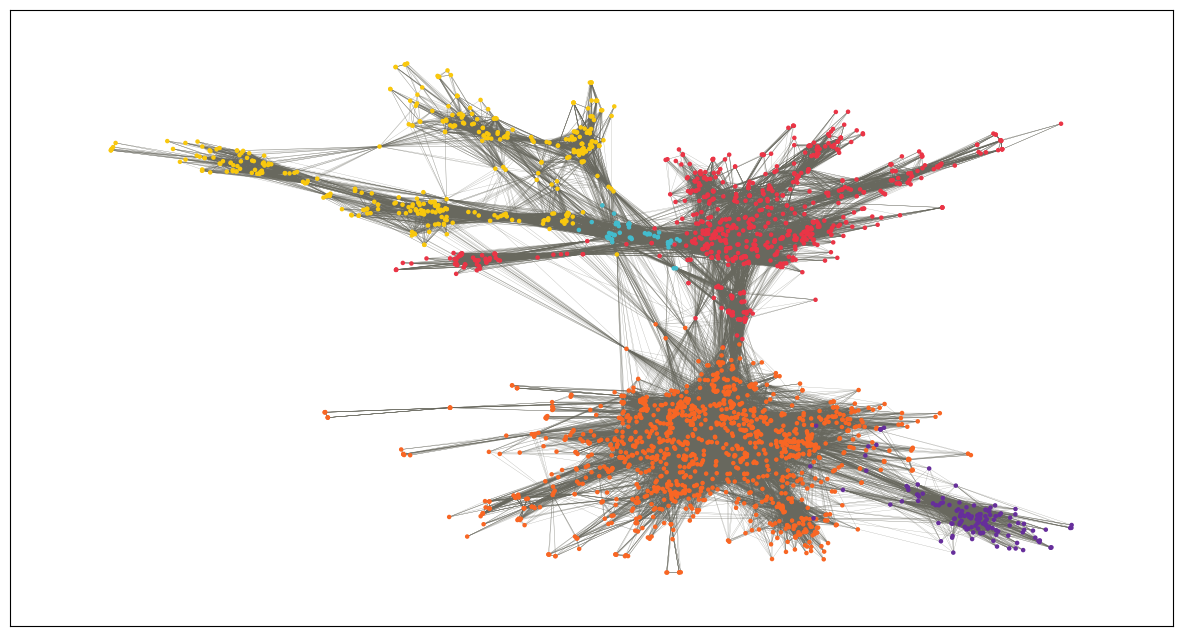

In [24]:
colors = ["#f9c80e", "#f86624", "#ea3546", "#662e9b", "#43bccd"]
color_labels = [colors[x] for x in kmeans.labels_]
plt.figure(figsize=(15,8))
G = nx.from_numpy_array(adj_matrix)
layout = nx.spring_layout(G, seed=1)
nx.draw_networkx_nodes(G, layout, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

Random walk embedding

In [25]:
import torch
from torch_geometric.nn import Node2Vec

In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [27]:
model = Node2Vec(
    adj_matrix,
    embedding_dim=128,
    walks_per_node=10,
    walk_length=20,
    context_size=10,
    p=1.0,
    q=1.0,
    num_negative_samples=1,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

ImportError: 'Node2Vec' requires either the 'pyg-lib' or 'torch-cluster' package

In [ ]:
!pip install torch-cluster -f https://pyg.org

Looking in links: https://pyg.org
  Using cached torch_cluster-1.6.3.tar.gz (54 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for torch-cluster
Failed to build torch-cluster


  DEPRECATION: Building 'torch-cluster' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'torch-cluster'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [91 lines of output]
      Compiling without OpenMP...
      Compiling without OpenMP...
      Compiling without OpenMP...
      Compiling without OpenMP...
      Compiling without OpenMP...
      Compiling without OpenMP...
      Compiling without OpenMP...
      Compiling without OpenMP...
      Compiling without OpenMP...
      Compiling without OpenMP...
      Compiling without OpenMP...
      Compili

In [44]:
adj_matrix.shape

(2567, 2567)

In [ ]:
from gensim.models import Word2Vec


random_walk_length = 100
random_walks = []
random_walks_count = 1000
jump_prob = 0.2

for r in tqdm(range(random_walks_count)):
    
    start = int(len(uniq_player_ids) * np.random.rand())    
    random_walk = [uniq_player_ids[start]]

    for i in range(random_walk_length):
        if np.random.rand() > jump_prob:
            jump = np.random.choice(uniq_player_ids, p=adj_matrix[start]/sum(adj_matrix[start]))
        else:
            jump = uniq_player_ids[int(len(uniq_player_ids) * np.random.rand())]
        random_walk.append(jump)
#pd.DataFrame(random_walk).value_counts()
    random_walks.append(random_walk)



  0%|          | 0/10000 [00:00<?, ?it/s]

In [122]:
model = Word2Vec(
    random_walks,
    vector_size=32,
    window=5,
    min_count=0,
    sg=1,
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [123]:
embeddings = np.array([model.wv[x] for x in uniq_player_ids])

In [124]:

clustering = KMeans(8).fit(embeddings)

In [125]:
clustering.labels_

array([1, 1, 1, ..., 5, 5, 4], shape=(2567,), dtype=int32)

In [126]:
from utils.score import nmi_regions
nmi_regions(clustering.labels_, uniq_player_ids, data)

0.4762028936439922

In [88]:
model.wv[uniq_player_ids[5]]

array([ 0.4082145 ,  0.6402487 , -0.3412304 , -0.4389349 , -0.26980853,
       -0.03383666,  0.522999  ,  0.6989449 ,  0.37770817,  0.05138464,
        0.01234799, -0.41080183,  0.38381037, -0.16333655,  0.43221536,
       -0.21954186, -0.6543283 , -0.38665566,  0.5969392 ,  0.96462494,
       -0.46771112, -0.32155254, -0.09591578, -0.7037404 ,  0.10886115,
        0.6318819 , -0.15501092,  0.1357709 ,  0.17495425,  0.25217202,
       -0.8815234 ,  0.17722219], dtype=float32)

In [82]:
np.mean(adj_matrix[start])

np.float64(0.018309310479158552)